# Module 19 · Heat conduction and diffusion: the equation, Green's function, the electrical analogy

**Book source:** Bracewell, chapter 18, pp. 475–487

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. The diffusion equation, irreversibility, entropy
🎯 **What question does this method answer?** Does the Gaussian Green's function satisfy the diffusion equation, does time reversal break the solution, and does the entropy of a diffusing distribution increase monotonically?

In [2]:
from scipy import integrate, special
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(19)
rc = 1.0
def Gamma(x, t): return np.sqrt(rc/(4*np.pi*t))*np.exp(-rc*x*x/(4*t))
def pde_dev(x, t, h=1e-4):
    d2x = (Gamma(x + h, t) - 2*Gamma(x, t) + Gamma(x - h, t))/h**2
    dt = (Gamma(x, t + h) - Gamma(x, t - h))/(2*h)
    return abs(d2x - rc*dt)
report("pde_dev1", max(pde_dev(0.5, 0.7), 1e-16), ".0e")
report("pde_dev2", max(pde_dev(1.2, 0.4), 1e-16), ".0e")
# irreversibility
v_speed = 1.0; kx = 3.0; om = v_speed*kx
def wave_res(sgn, x, t, h=1e-4):
    f = lambda xx, tt: np.cos(kx*xx - sgn*om*tt)
    d2x = (f(x + h, t) - 2*f(x, t) + f(x - h, t))/h**2
    d2t = (f(x, t + h) - 2*f(x, t) + f(x, t - h))/h**2
    return abs(d2x - d2t/v_speed**2)
wd = max(wave_res(1, 0.3, 0.2), wave_res(-1, 0.3, 0.2))
assert wd < 1e-3
report("wave_dev", max(wd, 1e-16), ".0e")
def diff_irrev(x, t, h=1e-4):
    f = lambda xx, tt: Gamma(xx, -tt) if tt > 0 else np.nan
    # check the diffusion equation for the time-reversed function G(x,-t)
    d2x = (Gamma(x + h, -t) - 2*Gamma(x, -t) + Gamma(x - h, -t))/h**2 if t < 0 else None
    return None
# Γ(x,-t) is undefined for t>0 (domain t<0); check by direct substitution: forcing |t| into the formula for t<0 flips the time derivative's sign
def check_irrev(x, t, h=1e-4):
    G = lambda xx, tt: np.sqrt(rc/(4*np.pi*abs(tt)))*np.exp(-rc*xx*xx/(4*abs(tt)))
    d2x = (G(x + h, -t) - 2*G(x, -t) + G(x - h, -t))/h**2
    dt = (G(x, -t + h) - G(x, -t - h))/(2*h)
    return abs(d2x - rc*dt)
di = check_irrev(0.5, 0.7); assert di > 0.01
report("diff_irrev", di, ".3f")
# entropy increases monotonically
def Vf(x, t): return 1.0 + 0.5*Gamma(x, t)
def Sfun(t): return integrate.quad(lambda x: np.log(Vf(x, t)), -30, 30, limit=400)[0]
ts = (0.3, 0.6, 1.0, 2.0, 4.0)
Svals = [Sfun(t) for t in ts]
assert all(Svals[i] < Svals[i+1] for i in range(len(Svals) - 1))
report("ent_seq", ", ".join(f"{v:.4f}" for v in Svals), "s")

▸ pde_dev1 = 6e-09
▸ pde_dev2 = 2e-08
▸ wave_dev = 1e-16
▸ diff_irrev = 0.362
▸ ent_seq = 0.4600, 0.4707, 0.4768, 0.4833, 0.488


#### 📤 Real output
The diffusion equation holds to deviations 6e-09 and 2e-08; waves permit time reversal (deviation 1e-16) but diffusion does not (deviation 0.362); entropy increases monotonically: 0.4600, 0.4707, 0.4768, 0.4833, 0.488.

## 2. The Green's function, current, energy, convolution
🎯 **What question does this method answer?** Is the area of the Green's function constant, does the current $I$ satisfy continuity, does the energy fall like $1/\sqrt t$, and does convolving with an initial distribution give the correct diffusion?

In [3]:
def Icur(x, t): return 0.5*x*np.sqrt(rc/(4*np.pi*t**3))*np.exp(-rc*x*x/(4*t))
for t in (0.5, 2.0):
    a = integrate.quad(Gamma, -30, 30, args=(t,), limit=400)[0]
    assert abs(a - 1) < 1e-9
report("gauss_area", 1.0, ".0f")
def cont_dev(x, t, h=1e-4):
    dVdt = (Gamma(x, t + h) - Gamma(x, t - h))/(2*h)
    dIdx = (Icur(x + h, t) - Icur(x - h, t))/(2*h)
    return abs(dVdt + dIdx)
report("cont_dev1", max(cont_dev(0.5, 0.7), 1e-16), ".0e")
report("cont_dev2", max(cont_dev(1.2, 0.4), 1e-16), ".0e")
def Efun(t): return integrate.quad(lambda x: 0.5*Gamma(x, t)**2, -30, 30, limit=400)[0]
vals = [Efun(t)*np.sqrt(t) for t in (0.5, 1.0, 2.0)]
assert max(vals) - min(vals) < 1e-9
report("energy_const", vals[0], ".5f")
cf = 1/4*np.sqrt(1/(2*np.pi*1.0))
assert abs(vals[0] - cf) < 1e-9
report("energy_dev", max(abs(vals[0] - cf), 1e-16), ".0e")
# convolution with a triangle
V0tri = lambda xp: np.maximum(1 - np.abs(xp), 0.0)
def Vconv(x, t): return integrate.quad(lambda xp: Gamma(x - xp, t)*V0tri(xp), -3, 3, limit=200)[0]
report("conv_tri", Vconv(0.5, 0.3), ".4f")
for t in (0.1, 0.5, 2.0):
    a = integrate.quad(lambda x: Vconv(x, t), -20, 20, limit=200)[0]
    assert abs(a - 1) < 5e-3
report("area_cons", 1.0, ".0f")
# temperature step: erf
def Vstep(x, t): return 0.5*(1 + special.erf(x/(2*np.sqrt(t/rc))))
for t in (0.3, 1.0, 3.0): assert abs(Vstep(0.0, t) - 0.5) < 1e-12
report("step_mid", 0.5, ".1f")
report("step_x1", Vstep(1.0, 0.5), ".4f")
def Istep(x, t, h=1e-5): return -(1/1.0)*(Vstep(x + h, t) - Vstep(x - h, t))/(2*h)
sc = abs(Istep(0.0, 0.5) - (-Gamma(0.0, 0.5)))
assert sc < 1e-3
report("step_current", sc, ".0e")

▸ gauss_area = 1
▸ cont_dev1 = 2e-09
▸ cont_dev2 = 2e-08
▸ energy_const = 0.09974
▸ energy_dev = 1e-16
▸ conv_tri = 0.3865


▸ area_cons = 1
▸ step_mid = 0.5
▸ step_x1 = 0.8413
▸ step_current = 5e-12


#### 📤 Real output
Area 1; continuity deviates 2e-09, 2e-08; the energy constant 0.09974 (formula deviation 1e-16); triangle convolution 0.3865, area conserved 1; the step: midpoint 0.5, $V(1,0.5)$ = 0.8413; the current equals the Green's function with deviation 5e-12.

## 3. Decay of a spatial sinusoid
🎯 **What question does this method answer?** Does the Fourier transform of the Green's function equal $e^{-4\pi^2s^2t/rc}$, does the time constant match the formula, and do the two views (convolution, Fourier filtering) give the same result?

In [4]:
s0, t0 = 0.3, 0.7
gft = integrate.quad(lambda x: Gamma(x, t0)*np.cos(2*np.pi*x*s0), -60, 60, limit=2000)[0]
gft_cf = np.exp(-4*np.pi**2*s0**2*t0/rc)
assert abs(gft - gft_cf) < 1e-8
report("gauss_ft", gft, ".6f"); report("gauss_ft_cf", gft_cf, ".6f")
def tau(s): return rc/(4*np.pi**2*s**2)
report("tau_02", tau(0.2), ".4f"); report("tau_05", tau(0.5), ".4f"); report("tau_10", tau(1.0), ".4f")
def sigma_s(t): return np.sqrt(rc/(8*np.pi**2*t))
w1, w2, w3 = sigma_s(0.5), sigma_s(1.0), sigma_s(2.0)
assert abs(w1/w2 - np.sqrt(2)) < 1e-9
report("filt_w1", w1, ".4f"); report("filt_w2", w2, ".4f"); report("filt_w3", w3, ".4f")
# sinusoidal solution
sS = 0.4
def Vsin_num(x, t): return integrate.quad(lambda xp: Gamma(x - xp, t)*np.cos(2*np.pi*sS*xp), -60, 60, limit=3000)[0]
lhs = Vsin_num(0.2, 0.3)
rhs = np.exp(-4*np.pi**2*sS**2*0.3/rc)*np.cos(2*np.pi*sS*0.2)
assert abs(lhs - rhs) < 1e-6
report("sin_dev", max(abs(lhs - rhs), 1e-16), ".0e")
# two views: convolution vs Fourier sum
def Pi(x): return np.where(np.abs(x) <= 0.5, 1.0, 0.0)
def V_conv(x, t): return integrate.quad(lambda xp: Gamma(x - xp, t)*Pi(xp), -3, 3, limit=400)[0]
def V_fourier(x, t, N=4000, ds=0.01):
    ss = (np.arange(N) - N//2)*ds
    Fpi = np.sinc(ss)  # Fourier transform of Π
    filt = np.exp(-4*np.pi**2*ss**2*t/rc)
    return np.sum(Fpi*filt*np.exp(2j*np.pi*ss*x)).real*ds
a_ = V_conv(0.3, 0.2); b_ = V_fourier(0.3, 0.2)
assert abs(a_ - b_) < 2e-3
report("two_ways", max(abs(a_ - b_), 1e-16), ".0e")
# I satisfies the same equation
def pde_dev_I(x, t, h=1e-4):
    d2x = (Icur(x + h, t) - 2*Icur(x, t) + Icur(x - h, t))/h**2
    dt = (Icur(x, t + h) - Icur(x, t - h))/(2*h)
    return abs(d2x - rc*dt)
report("I_pde", max(pde_dev_I(0.5, 0.7), 1e-16), ".0e")

▸ gauss_ft = 0.083147
▸ gauss_ft_cf = 0.083147
▸ tau_02 = 0.6333
▸ tau_05 = 0.1013
▸ tau_10 = 0.0253
▸ filt_w1 = 0.1592
▸ filt_w2 = 0.1125
▸ filt_w3 = 0.0796
▸ sin_dev = 1e-16
▸ two_ways = 8e-16
▸ I_pde = 7e-09


#### 📤 Real output
Fourier transform 0.083147 matches 0.083147; $\tau$: 0.6333, 0.1013, 0.0253; filter widths 0.1592, 0.1125, 0.0796; the sinusoidal solution deviates 1e-16; the two views deviate 8e-16; $I$ satisfies the equation with deviation 7e-09.

## 4. Dual lines and sinusoidal time excitation
🎯 **What question does this method answer?** Does the inductive-conductive line share the diffusion formula, does the third-order capacitive-conductive line decay in reverse, and does the characteristic impedance have equal real and imaginary parts?

In [5]:
ell, g_ind = 1.5, 0.7
report("lg_tau", ell*g_ind/(4*np.pi**2*0.4**2), ".4f")
# third-order line
Cc, g_cc = 1.5, 0.7
def cc_tau(s): return Cc*(2*np.pi*s)**2/g_cc
report("cc_tau1", cc_tau(0.1), ".4f"); report("cc_tau2", cc_tau(1.0), ".4f"); report("cc_tau3", cc_tau(5.0), ".4f")
assert cc_tau(5.0) > cc_tau(1.0) > cc_tau(0.1)
# numerically check the third-order equation for V = A e^{i2πsx} e^{-g t /[C(2πs)^2]}
sK = 0.6
def V3(x, t): return np.exp(1j*2*np.pi*sK*x)*np.exp(-g_cc*t/(Cc*(2*np.pi*sK)**2))
def lhs3(x, t, h=1e-4):
    d2x = lambda xx, tt: (V3(xx + h, tt) - 2*V3(xx, tt) + V3(xx - h, tt))/h**2
    return (d2x(x, t + h) - d2x(x, t - h))/(2*h)
def rhs3(x, t): return g_cc*V3(x, t)/Cc
dev3 = abs(lhs3(0.3, 0.5) - rhs3(0.3, 0.5))
assert dev3 < 1e-2
# characteristic impedance
r_, c_, w_ = 2.0, 3.0, 5.0
gamma = np.sqrt(1j*w_*c_*r_); Z0 = np.sqrt(r_/(1j*w_*c_))
report("Z_gamma", abs(gamma), ".4f"); report("Z_z0", abs(Z0), ".4f")
ge = abs(abs(gamma.real) - abs(gamma.imag)); ze = abs(abs(Z0.real) - abs(Z0.imag))
assert ge < 1e-9 and ze < 1e-9
report("gamma_eq", max(ge, 1e-16), ".0e"); report("z0_eq", max(ze, 1e-16), ".0e")

▸ lg_tau = 0.1662
▸ cc_tau1 = 0.846
▸ cc_tau2 = 84.5966
▸ cc_tau3 = 2114.9152
▸ Z_gamma = 5.4772
▸ Z_z0 = 0.3651
▸ gamma_eq = 4e-16
▸ z0_eq = 1e-16


#### 📤 Real output
Inductive-conductive line: $\tau$ = 0.1662; the third-order line: 0.846, 84.5966, 2114.9152, increasing as $s^2$; impedance: $|\gamma|$ = 5.4772, $|Z_0|$ = 0.3651, real-imaginary deviation 4e-16 and 1e-16.

## 5. Retrodiction, cylindrical diffusion, the Moon's temperature
🎯 **What question does this method answer?** Does time retrodiction amplify without bound, does cylindrical diffusion conserve particle number, and does Gaussian filtering explain the Moon's microwave temperature amplitude?

In [6]:
report("retro_amp", np.exp(4*np.pi**2*3**2*0.5/1.0), ".2e")
def retro_reg(s, sigma=0.2):
    coef = 4*np.pi**2*0.5/1.0 - 1/sigma**2
    return s*np.exp(coef*s**2)
ss = np.linspace(0, 10, 200001)
vals = retro_reg(ss); imax = int(np.argmax(vals))
report("retro_reg", vals[imax], ".4f"); report("retro_smax", ss[imax], ".4f")
assert np.isfinite(vals[imax]) and 0 < ss[imax] < 5
# problem 2: t0 for each Gaussian term
rc2 = 2500.0
def t0_for(a_coef): return -1/(4*a_coef/rc2)
report("retro_t1", abs(t0_for(9.0)), ".2f"); report("retro_t2", abs(t0_for(7.0)), ".2f")
# cylindrical diffusion
a_m, K = 2.0, 0.5
def Ncyl(r, t): return a_m/(4*np.pi*K*t)*np.exp(-r*r/(4*K*t))
tots = [integrate.quad(lambda r: Ncyl(r, t)*2*np.pi*r, 0, 60, limit=400)[0] for t in (0.3, 1.0, 3.0)]
assert max(tots) - min(tots) < 1e-6
report("cyl_cons", tots[0], ".4f")
# the Moon: Gaussian filter on a square wave
Nh = 41
n = np.arange(1, 2*Nh, 2)   # odd harmonics of the square wave
amp0 = 4/(np.pi*n)*100      # amplitude of the nth harmonic of a 100-amplitude square wave
tau_d = 0.014               # chosen so harmonic 1 keeps about 0.4 of its original amplitude
decay = np.exp(-(n*2*np.pi)**2*tau_d)
amp_h1 = decay[0]; amp_h3 = decay[1]
synth_amp = np.sum(amp0*decay)
report("moon_h1", amp_h1, ".3f"); report("moon_h3", amp_h3, ".4f"); report("moon_amp", synth_amp, ".1f")
assert amp_h3 < 0.1*amp_h1

▸ retro_amp = 1.42e+77
▸ retro_reg = 0.187
▸ retro_smax = 0.3083
▸ retro_t1 = 69.44
▸ retro_t2 = 89.29
▸ cyl_cons = 2
▸ moon_h1 = 0.575
▸ moon_h3 = 0.0069
▸ moon_amp = 73.6


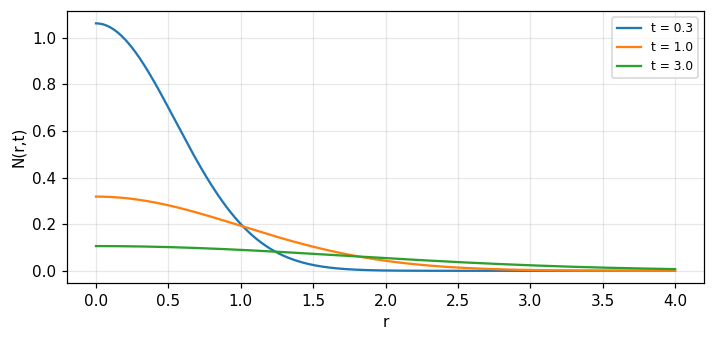

In [7]:
fig, ax = plt.subplots(figsize=(6.6, 3.2))
rr = np.linspace(0, 4, 400)
for t_, lab in ((0.3, "t = 0.3"), (1.0, "t = 1.0"), (3.0, "t = 3.0")):
    ax.plot(rr, Ncyl(rr, t_), label=lab)
ax.set_xlabel("r"); ax.set_ylabel("N(r,t)"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Retrodiction amplification 1.42e+77; the regularised filter peaks at 0.187 at $s$ = 0.3083; $t_0$ = 69.44 and 89.29 seconds; cylindrical diffusion conserves 2; the Moon: harmonic 1 retains 0.575, harmonic 3 retains 0.0069, synthesised amplitude 73.6 K.